# LRN Training Example

This notebook trains an `LRNModel` on multilayer SIMNRA datasets discovered under a user-provided root folder.

The workflow is:

1. Recursively scan an absolute dataset root for `.h5`, `.hdf5`, or `.hf5` files.
2. Pad each case into the open-parameter layout of the max-layer dataset.
3. Build an LRN schema from that max-layer input spec.
4. Train the network on one selected output method such as `RBS`.


In [1]:
from __future__ import annotations

from pathlib import Path
import gc
import sys 
sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np
import torch

from ibamlkit.data import DatasetBatchReader
from ibamlkit.models.forward import LRNModel, LTNModel, MLPModel, CNNModel, CNN2Model, build_lrn_model_schema
from ibamlkit.pileup import (
    apply_channel_space_pileup,
    compute_rebin_energy_edges,
    convert_energy_spectra_to_channel_space_and_pileup,
    convert_to_channel_space_and_pileup_batch,
    fast_pileup_batch,
    rebin_spectra_to_energy_space,
    rebin_histogram,
    resolve_channel_conversion_arrays,
)
from ibamlkit.training import (
    ConstantFactorTransform,
    EpochSchedule,
    IdentityTransform,
    Chi2Loss,
    LayerwiseConcentrationNormalizer,
    ParameterBoundMinMaxScaler,
    SelectiveMinMaxScaler,
    ModelPackageArtifacts,
    PeakAwareLoss,
    SupervisedTrainer,
    export_as_package,
    TransformPipeline,
    prepare_variable_layer_surrogate_dataset,
    shuffle_in_unison,
    split_train_val_test,
)
from ibamlkit.validation import (
    SIMNRABatchSimulator,
    SimulationBatchResult,
    SurrogateBatchSimulator,
    calculate_chi2_batch,
    fit_open_parameters,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


c:\Users\local_admin\.conda\envs\DL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import re
from pathlib import Path

DATASET_FILE_SUFFIXES = {".h5", ".hdf5", ".hf5"}

_LAYER_FILE_RE = re.compile(r"^multilayer_(\d+)_(\d+)$")


def require_absolute_directory(path: Path) -> Path:
    path = Path(path)
    if not path.is_absolute():
        raise ValueError(f"Dataset scan root must be an absolute path, got: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Dataset scan root does not exist: {path}")
    if not path.is_dir():
        raise NotADirectoryError(f"Dataset scan root is not a directory: {path}")
    return path


def _extract_layer_number(path: Path) -> int | None:
    match = _LAYER_FILE_RE.match(path.stem)
    if match is None:
        return None
    return int(match.group(1))


def collect_dataset_file_groups(
    scan_root: Path,
    min_layer_number: int = 1,
    max_layer_number: int = 10,
) -> list[tuple[Path, list[Path]]]:
    scan_root = require_absolute_directory(scan_root)

    if min_layer_number > max_layer_number:
        raise ValueError(
            f"min_layer_number must be <= max_layer_number, got "
            f"{min_layer_number} > {max_layer_number}"
        )

    grouped_paths: dict[Path, list[Path]] = {}

    for path in sorted(scan_root.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in DATASET_FILE_SUFFIXES:
            continue

        layer_number = _extract_layer_number(path)
        if layer_number is None:
            continue

        if not (min_layer_number <= layer_number <= max_layer_number):
            continue

        grouped_paths.setdefault(path.parent, []).append(path)

    if not grouped_paths:
        raise FileNotFoundError(
            f"No dataset files with suffixes {sorted(DATASET_FILE_SUFFIXES)} "
            f"and layer numbers in [{min_layer_number}, {max_layer_number}] "
            f"were found under {scan_root}"
        )

    return sorted(grouped_paths.items(), key=lambda item: str(item[0]).lower())


def load_case_dataset(paths: list[Path]):
    reader = DatasetBatchReader()
    dataset = reader.load_many(paths)
    return dataset, paths


def print_array_stats(name: str, x: np.ndarray) -> None:
    x = np.asarray(x)
    if x.ndim == 0:
        print(f"{name}: value={float(x):.6g}")
        return
    mean_value = float(np.mean(x, dtype=np.float64))
    min_value = float(np.min(x))
    max_value = float(np.max(x))
    if x.size <= 1_000_000:
        median_value = float(np.median(x))
        print(
            f"{name}: shape={x.shape}, min={min_value:.6g}, max={max_value:.6g}, "
            f"mean={mean_value:.6g}, median={median_value:.6g}"
        )
    else:
        print(
            f"{name}: shape={x.shape}, min={min_value:.6g}, max={max_value:.6g}, "
            f"mean={mean_value:.6g}"
        )

In [3]:
dataset_root = Path(r"D:/IBAMLKit/examples/datasets/multilayer_7_elements_seed_1")  # Update this path to your dataset locatio
#dataset_root = Path(r"D:/IBAMLKit/examples/datasets/14el")  # Update this path to your dataset locatio
method_name = "RBS"
target_width = 5000 #NRA length 6000, RBS 8400
target_scale_factor = 1e-6
energy_bin_width = 2.5
energy_spectrum_scale = 1.0
seed = 7
val_count = 5000
test_count = 5000

dataset_root = require_absolute_directory(dataset_root)
case_groups = collect_dataset_file_groups(dataset_root, min_layer_number=1, max_layer_number=7)
datasets = []
for case_dir, paths in case_groups:
    try:
        dataset, paths = load_case_dataset(paths)
        n_layers = int(dataset.input_spec.generation_info.get("n_layers", 0))
        print(
            f"Loaded case {case_dir}: {len(paths)} file(s), "
            f"samples={dataset.sample_count}, n_layers={n_layers}"
        )
        datasets.append(dataset)
    except Exception as e:
        print(f"Error loading case {case_dir}: {e}")

if not datasets:
    raise RuntimeError(f"No datasets could be loaded from {dataset_root}")

reference_dataset = max(
    datasets,
    key=lambda dataset: int(dataset.input_spec.generation_info.get("n_layers", 0)),
)
bootstrap_schema = build_lrn_model_schema(
    reference_dataset.input_spec,
    model_name=f"lrn_{method_name.lower()}",
    task_method_names=[method_name],
    output_spectra_lengths={method_name: 1},
)
prepared = prepare_variable_layer_surrogate_dataset(
    datasets,
    schema=bootstrap_schema,
    method_name=method_name,
)
reference_dataset = prepared.reference_dataset
reference_open_parameter_names = [parameter.name for parameter in reference_dataset.input_spec.open_parameters]
full_open_parameter_values = np.asarray(prepared.inputs_full, dtype=np.float32)
channel_targets_raw = np.asarray(prepared.targets, dtype=np.float32)
channel_target_lengths = prepared.target_lengths
if channel_target_lengths is not None:
    channel_target_lengths = np.asarray(channel_target_lengths, dtype=np.int32)
    valid_mask = channel_target_lengths > 0
    dropped_count = int((~valid_mask).sum())
    if dropped_count:
        full_open_parameter_values = np.asarray(full_open_parameter_values[valid_mask], dtype=np.float32)
        channel_targets_raw = np.asarray(channel_targets_raw[valid_mask], dtype=np.float32)
        channel_target_lengths = np.asarray(channel_target_lengths[valid_mask], dtype=np.int32)
        prepared_inputs_selected = np.asarray(prepared.inputs_selected[valid_mask], dtype=np.float32)
        print(f"Discarded {dropped_count} invalid samples with zero-length {method_name} spectra.")
    else:
        prepared_inputs_selected = np.asarray(prepared.inputs_selected, dtype=np.float32)
else:
    prepared_inputs_selected = np.asarray(prepared.inputs_selected, dtype=np.float32)

sample_count = int(prepared_inputs_selected.shape[0])
permutation = np.random.default_rng(seed).permutation(sample_count)
prepared_inputs_selected = np.asarray(prepared_inputs_selected[permutation], dtype=np.float32)
full_open_parameter_values = np.asarray(full_open_parameter_values[permutation], dtype=np.float32)

calibration_offset_all, calibration_linear_all, calibration_quadratic_all, normalization_factor_all = resolve_channel_conversion_arrays(
    reference_dataset.input_spec,
    reference_open_parameter_names,
    full_open_parameter_values,
    method_name=method_name,
    energy_spectrum_scale=energy_spectrum_scale,
)

energy_bin_edges = compute_rebin_energy_edges(
    channel_targets_raw,
    channel_target_lengths,
    calibration_offset=calibration_offset_all,
    calibration_linear=calibration_linear_all,
    calibration_quadratic=calibration_quadratic_all,
    energy_bin_width=energy_bin_width,
    row_indices=permutation,
    show_progress=True,
    progress_desc=f"Rebinning {method_name}",
)

energy_output_width = min(target_width, max(energy_bin_edges.shape[0] - 1, 0))
artifact_dir = Path.cwd() / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
energy_targets_path = artifact_dir / f"{method_name.lower()}_energy_targets.dat"
try :
    energy_targets_raw = np.memmap(
        energy_targets_path,
        mode="w+",
        dtype=np.float32,
        shape=(sample_count, energy_output_width),
    )
except Exception as e: pass

energy_target_lengths = np.zeros((sample_count,), dtype=np.int32)
rebin_spectra_to_energy_space(
    channel_targets_raw,
    channel_target_lengths,
    calibration_offset=calibration_offset_all,
    calibration_linear=calibration_linear_all,
    calibration_quadratic=calibration_quadratic_all,
    energy_bin_width=energy_bin_width,
    target_width=target_width,
    energy_spectrum_scale=target_scale_factor,
    row_indices=permutation,
    energy_edges=energy_bin_edges,
    out=energy_targets_raw,
    show_progress=True,
    progress_desc=f"Rebinning {method_name}",
)

schema = build_lrn_model_schema(
    reference_dataset.input_spec,
    model_name=f"lrn_{method_name.lower()}_e_space",
    task_method_names=[method_name],
    output_spectra_lengths={method_name: int(energy_targets_raw.shape[1])},
)
x = prepared_inputs_selected
y = energy_targets_raw
y_lengths = energy_target_lengths

output_transform = ConstantFactorTransform(target_scale_factor)
output_transform.fit(np.zeros((1, y.shape[1]), dtype=np.float32))

print(f"Raw channel-space targets released; E-space targets shape={y.shape}, dtype={y.dtype}")

del prepared
del channel_targets_raw
gc.collect()

print("Dataset root:", dataset_root)
print("Reference layer count:", reference_dataset.input_spec.generation_info.get("n_layers"))
print("Input matrix shape:", x.shape)
print("E-space output matrix shape:", y.shape)
print("Energy bin width:", energy_bin_width)
print("Energy bin edge count:", energy_bin_edges.shape[0])
print("Schema input dimension:", schema.inputs.dimension)
print("Schema E-space output width:", schema.outputs.spectra_lengths[method_name])

Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_1: 1 file(s), samples=149983, n_layers=1
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_2: 1 file(s), samples=149612, n_layers=2
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_3: 1 file(s), samples=149680, n_layers=3
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_4: 1 file(s), samples=149687, n_layers=4
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_5: 1 file(s), samples=149778, n_layers=5
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_6: 1 file(s), samples=149789, n_layers=6
Loaded case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_7: 1 file(s), samples=149944, n_layers=7


Rebinning RBS output: 100%|██████████| 1048473/1048473 [00:30<00:00, 34551.68spectra/s]

Raw channel-space targets released; E-space targets shape=(1048473, 3106), dtype=float32
Dataset root: D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1
Reference layer count: 7
Input matrix shape: (1048473, 56)
E-space output matrix shape: (1048473, 3106)
Energy bin width: 2.5
Energy bin edge count: 3107
Schema input dimension: 56
Schema E-space output width: 3106


In [4]:
split = split_train_val_test(
    x,
    y,
    val_count=val_count,
    test_count=test_count,
    target_lengths=y_lengths,
)

x_train = split.train_inputs
y_train = split.train_targets
x_val = split.val_inputs
y_val = split.val_targets
x_test = split.test_inputs
y_test = split.test_targets
test_lengths = split.test_target_lengths

train_count = x_train.shape[0]
val_end = train_count + x_val.shape[0]
full_open_parameter_values_train = full_open_parameter_values[:train_count]
full_open_parameter_values_val = full_open_parameter_values[train_count:val_end]
full_open_parameter_values_test = full_open_parameter_values[val_end:]
concentration_normalizer = LayerwiseConcentrationNormalizer.from_schema(schema)
feature_scaler = ParameterBoundMinMaxScaler.from_parameters(
    reference_dataset.input_spec.open_parameters,
    passthrough_kinds=("concentration",),
    fixed_bounds_by_kind={"thickness": (0.0, 100000.0)},
    low=0.0,
    high=1.0,
)
input_scaler = TransformPipeline([
    concentration_normalizer,
    feature_scaler,
])
input_scaler.fit(x_train)
x_scaled_path = artifact_dir / f"{method_name.lower()}_input_scaled.dat"
x_scaled = np.memmap(
    x_scaled_path,
    mode="w+",
    dtype=np.float32,
    shape=x.shape,
)
scale_chunk_size = 50000
for start in range(0, x.shape[0], scale_chunk_size):
    end = min(start + scale_chunk_size, x.shape[0])
    x_scaled[start:end] = input_scaler.transform(x[start:end])
x_train_scaled = x_scaled[:train_count]
x_val_scaled = x_scaled[train_count:val_end]
x_test_scaled = x_scaled[val_end:]
del x_train, x_val, x
gc.collect()

print("Train:", x_train_scaled.shape, y_train.shape)
print("Val:", x_val_scaled.shape, y_val.shape)
print("Test:", x_test_scaled.shape, y_test.shape)
print(
    "Input transform:",
    "layerwise concentration normalization + parameter-bound min-max scaling",
    f"pass-through concentration columns={(~feature_scaler.scale_columns).sum()}",
    f"fixed-range columns={feature_scaler.fixed_range_columns.sum()}",
    f"scaled columns={feature_scaler.scale_columns.sum()}",
)
print("Channel-space test targets: omitted to avoid duplicating the raw matrix")

Train: (1038473, 56) (1038473, 3106)
Val: (5000, 56) (5000, 3106)
Test: (5000, 56) (5000, 3106)
Input transform: layerwise concentration normalization + parameter-bound min-max scaling pass-through concentration columns=49 fixed-range columns=7 scaled columns=7
Channel-space test targets: omitted to avoid duplicating the raw matrix


In [5]:
lrn_model = LRNModel(
    schema,
    hidden_size= 256,
    contribution_size= 512,
    setup_embedding_dim = 32,
    layer_embedding_dim = 256,
    block_hidden_sizes = (768, 768),
    decoder_hidden_sizes = (768, 768),
    refiner_hidden_channels=32,
    refiner_kernel_size=8,
)

print("LRN Model created")
print(f"  Input dimension: {lrn_model.input_dimension}")
print(f"  Output dimension: {lrn_model.output_feature_dimension}")
print(f"  Total parameters: {sum(p.numel() for p in lrn_model.parameters()):,}")

LRN Model created
  Input dimension: 56
  Output dimension: 0
  Total parameters: 6,634,981


In [ ]:
artifact_dir = Path.cwd() / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / f"lrn_{method_name.lower()}_state_dict_lrnscaler_7el.pt"
lrn_model.load_state_dict(torch.load(artifact_path, map_location=device)["model_state_dict"])

In [6]:
lrn_trainer = SupervisedTrainer(
    device=device,
    loss_fn=Chi2Loss(),
    optimizer_name="adamw",
    weight_decay=0.001,
    max_grad_norm=5.0,
    early_stopping_patience=50,
    track_train_loss=False,
    batch_shuffle_mode="full",
    shuffle_block_size=65536,
    verbose=True,
    log_every_epochs=1,
)

lrn_result = lrn_trainer.fit(
    lrn_model,
    train_inputs=x_train_scaled,
    train_targets=y_train,
    val_inputs=x_val_scaled,
    val_targets=y_val,
    schedule=[
        EpochSchedule(learning_rate=1e-3, epochs=20, batch_size=1024),
        EpochSchedule(learning_rate=5e-4, epochs=20, batch_size=1024),
        EpochSchedule(learning_rate=1e-4, epochs=20, batch_size=1024),
        EpochSchedule(learning_rate=5e-5, epochs=10, batch_size=1024),
    ],
)

print("LRN Training completed:")
print(lrn_result)

Training started: device=cuda, train_samples=1038473, val_samples=5000, input_dim=56, target_dim=3106
Initial losses: val=2.108810
Phase 1/4: lr=0.001, epochs=20, batch_size=1024
  epoch 1/20 (global 1): val=0.360467, best=0.360467, improved
  epoch 2/20 (global 2): val=0.068884, best=0.068884, improved
  epoch 3/20 (global 3): val=0.040250, best=0.040250, improved
  epoch 4/20 (global 4): val=0.025477, best=0.025477, improved
  epoch 5/20 (global 5): val=0.019347, best=0.019347, improved
  epoch 6/20 (global 6): val=0.036891, best=0.019347, stale=1
  epoch 7/20 (global 7): val=0.022984, best=0.019347, stale=2
  epoch 8/20 (global 8): val=0.010684, best=0.010684, improved
  epoch 9/20 (global 9): val=0.009388, best=0.009388, improved
  epoch 10/20 (global 10): val=0.009578, best=0.009388, stale=1
  epoch 11/20 (global 11): val=0.009071, best=0.009071, improved
  epoch 12/20 (global 12): val=0.016207, best=0.009071, stale=1
  epoch 13/20 (global 13): val=0.008197, best=0.008197, improve

Predicted E-space test spectra: shape=(5000, 3106), dtype=float32
E-space test valid spectra: 4993
E-space test relative-error statistics:
  min   : 0.008742203507473267
  p01   : 0.03683908302659829
  p05   : 0.058847662849961
  p10   : 0.07366166947473567
  p25   : 0.11607046191950379
  p50   : 0.18132825678313266
  p75   : 0.27579021041592866
  p90   : 0.3832467836466872
  p95   : 0.47155392640703975
  p99   : 0.700760055180847
  mean  : 0.21494615676909634
  max   : 2.5885358981211577


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\2094479170.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


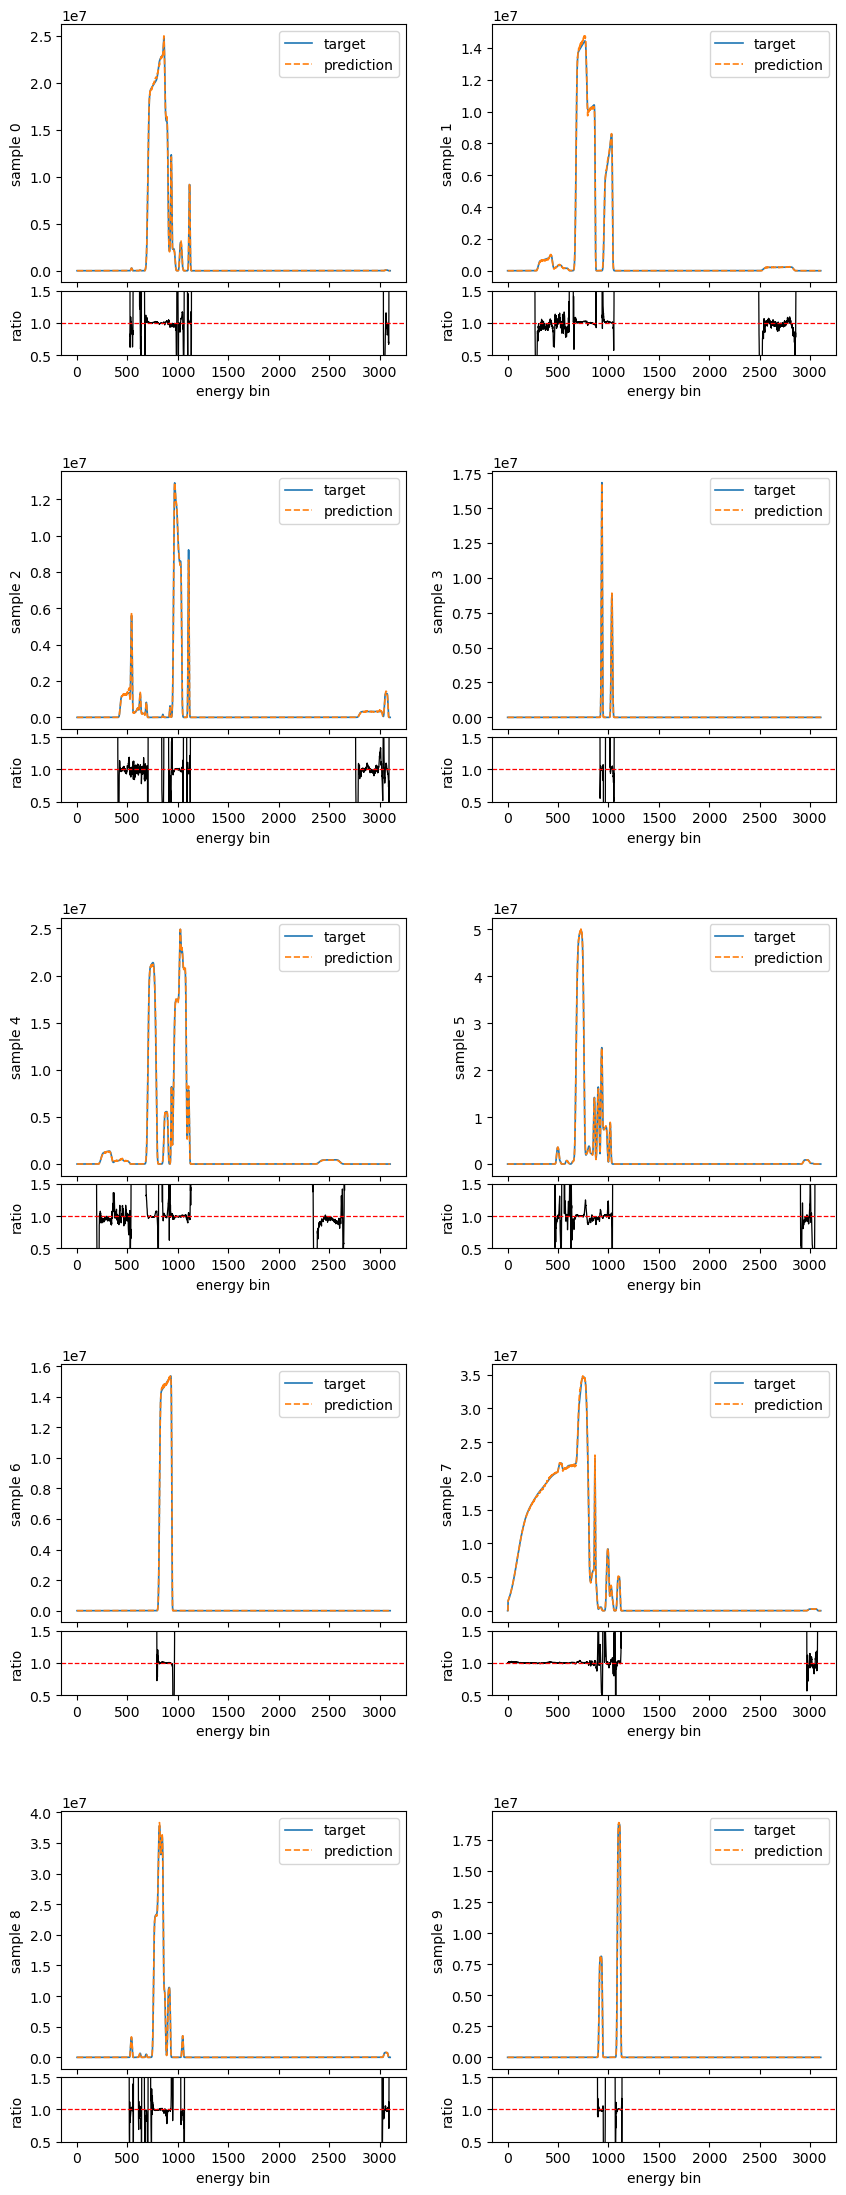

In [7]:
pred_test_transformed = lrn_model.predict(x_test_scaled).cpu().numpy()
pred_test_e = np.empty_like(pred_test_transformed, dtype=np.float32)
output_transform.inverse_transform(pred_test_transformed, out=pred_test_e)
y_test_e = np.empty_like(y_test, dtype=np.float32)
output_transform.inverse_transform(y_test, out=y_test_e)
del pred_test_transformed

print(f"Predicted E-space test spectra: shape={pred_test_e.shape}, dtype={pred_test_e.dtype}")

valid_bin_mask = y_test_e > 1e+3
sample_rel_err_means = []

for sample_index in range(y_test_e.shape[0]):
    sample_mask = valid_bin_mask[sample_index]
    if not np.any(sample_mask):
        continue

    sample_rel_err = (
        np.abs(y_test_e[sample_index, sample_mask] - pred_test_e[sample_index, sample_mask])
        / y_test_e[sample_index, sample_mask]
    ).astype(np.float64)

    sample_rel_err_means.append(np.mean(sample_rel_err))

sample_rel_err_means = np.asarray(sample_rel_err_means, dtype=np.float64)

if sample_rel_err_means.size == 0:
    print("E-space test: no spectra have bins with data > 10.")
else:
    print(f"E-space test valid spectra: {sample_rel_err_means.size}")
    print("E-space test relative-error statistics:")
    print("  min   :", float(np.min(sample_rel_err_means)))
    print("  p01   :", float(np.percentile(sample_rel_err_means, 1.0)))
    print("  p05   :", float(np.percentile(sample_rel_err_means, 5.0)))
    print("  p10   :", float(np.percentile(sample_rel_err_means, 10.0)))
    print("  p25   :", float(np.percentile(sample_rel_err_means, 25.0)))
    print("  p50   :", float(np.percentile(sample_rel_err_means, 50.0)))
    print("  p75   :", float(np.percentile(sample_rel_err_means, 75.0)))
    print("  p90   :", float(np.percentile(sample_rel_err_means, 90.0)))
    print("  p95   :", float(np.percentile(sample_rel_err_means, 95.0)))
    print("  p99   :", float(np.percentile(sample_rel_err_means, 99.0)))
    print("  mean  :", float(np.mean(sample_rel_err_means)))
    print("  max   :", float(np.max(sample_rel_err_means)))

n_plot = min(10, x_test_scaled.shape[0])
n_cols = 2
n_rows = int(np.ceil(n_plot / n_cols))

fig = plt.figure(figsize=(10, 5.5 * n_rows))
outer = fig.add_gridspec(n_rows, n_cols, wspace=0.25, hspace=0.35)

for panel_index in range(n_plot):
    row = panel_index // n_cols
    col = panel_index % n_cols

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.05)
    ax_top = fig.add_subplot(inner[0])
    ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

    target = y_test_e[panel_index]
    pred = pred_test_e[panel_index]

    ratio = np.full_like(target, np.nan, dtype=np.float32)
    ratio_mask = target > 0.0
    ratio[ratio_mask] = pred[ratio_mask] / target[ratio_mask]

    e_length = y_test_e.shape[1]
    ax_top.plot(target[:e_length], label="target", linewidth=1.2)
    ax_top.plot(pred[:e_length], linestyle="--", label="prediction", linewidth=1.2)
    ax_top.set_ylabel(f"sample {panel_index}")
    if panel_index == 0:pass
    ax_top.legend()

    ax_bottom.plot(ratio[:e_length], color="black", linewidth=0.9)
    ax_bottom.axhline(1.0, color="red", linestyle="--", linewidth=0.9)
    ax_bottom.set_ylabel("ratio")
    ax_bottom.set_xlabel("energy bin")
    ax_bottom.set_ylim(0.5, 1.5)

    plt.setp(ax_top.get_xticklabels(), visible=False)

for panel_index in range(n_plot, n_rows * n_cols):
    row = panel_index // n_cols
    col = panel_index % n_cols
    ax_empty = fig.add_subplot(outer[row, col])
    ax_empty.set_visible(False)

fig.tight_layout()
plt.savefig(artifact_dir / f"{method_name.lower()}_e_space_predictions_7el_upto7layers.pdf", bbox_inches="tight")

In [ ]:
package_path = export_as_package(
    lrn_model,
    ModelPackageArtifacts(
        input_spec=reference_dataset.input_spec,
        input_scaler=input_scaler,
        output_transform=output_transform,
        metadata={
            "method_name": method_name,
            "energy_bin_width": energy_bin_width,
            "energy_output_width": int(y.shape[1]),
        },
    ),
    artifact_dir / f"lrn_{method_name.lower()}_package_14el_2mil_lrnscaler.zip",
)
print("Exported package:", package_path)



In [8]:
artifact_dir = Path.cwd() / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / f"lrn_{method_name.lower()}_state_dict_lrnscaler_7el_upto7layers.pt"
torch.save(
    {
        "model_state_dict": lrn_model.state_dict(),
        "schema": schema,
        "input_scaler": input_scaler,
        "output_transform": output_transform,
        #"training_result": result,
    },
    artifact_path,
)
print("Saved:", artifact_path)

Saved: d:\IBAMLKit\examples\artifacts\lrn_rbs_state_dict_lrnscaler_7el_upto7layers.pt


Loaded generalization case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1_11_15_layers\layers_11: 1 file(s), samples=15000, n_layers=11


Rebinning RBS 11 layers output: 100%|██████████| 15000/15000 [00:00<00:00, 33033.32spectra/s]


Layer case 11: samples=15000, valid spectra=15000, min=0.017784, p01=0.043658, p05=0.0684102, p10=0.0843603, p25=0.116927, p50=0.16175, p75=0.219661, p90=0.279894, p95=0.326085, p99=0.437487, mean=0.175888, max=6.21676


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\4031044095.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.985])


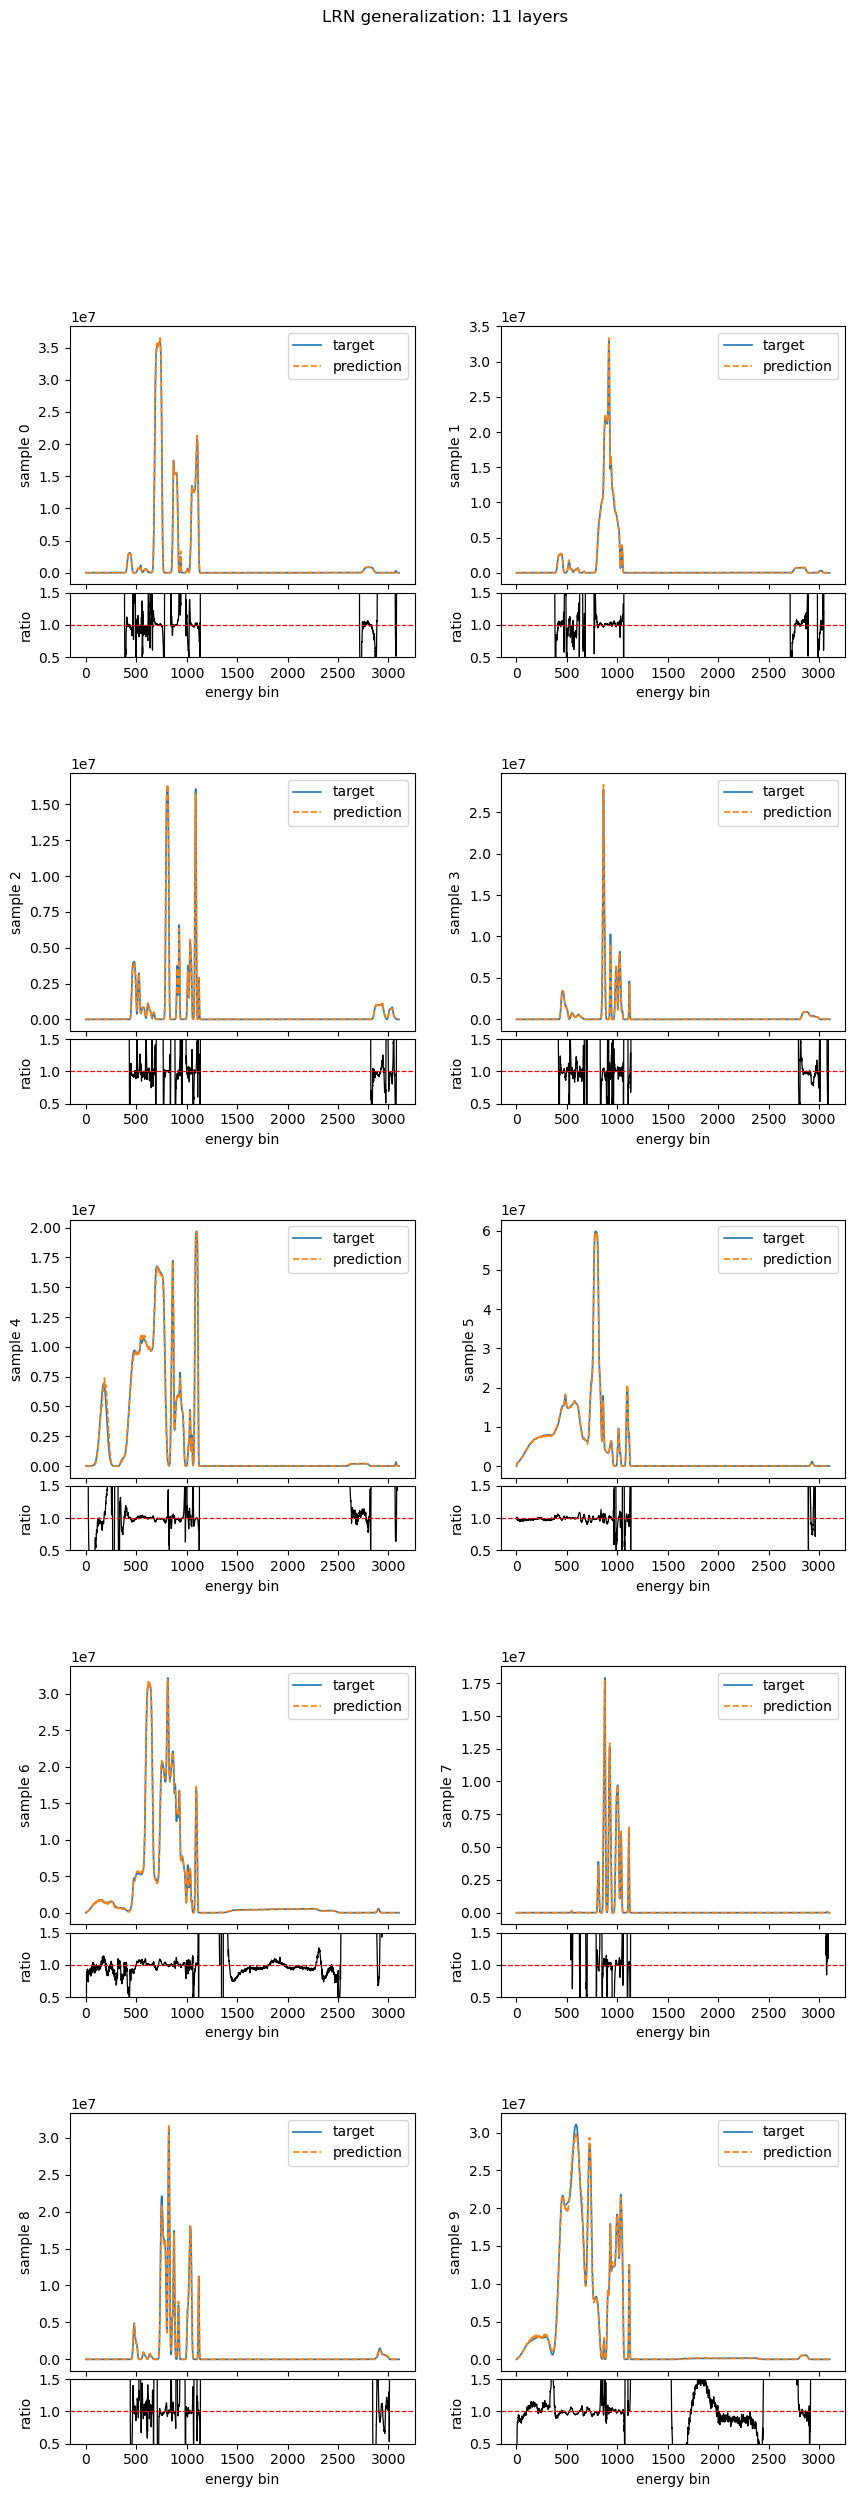

Saved figure: d:\IBAMLKit\examples\artifacts\rbs_e_space_predictions_upto7layermodel_11layers_generalization.pdf
Loaded generalization case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1_11_15_layers\layers_12: 1 file(s), samples=15000, n_layers=12


Rebinning RBS 12 layers output: 100%|██████████| 15000/15000 [00:00<00:00, 24007.02spectra/s]


Layer case 12: samples=15000, valid spectra=15000, min=0.015541, p01=0.0460749, p05=0.0694749, p10=0.0853257, p25=0.117941, p50=0.164773, p75=0.2227, p90=0.28745, p95=0.335449, p99=0.449147, mean=0.180108, max=8.43337


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\4031044095.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.985])


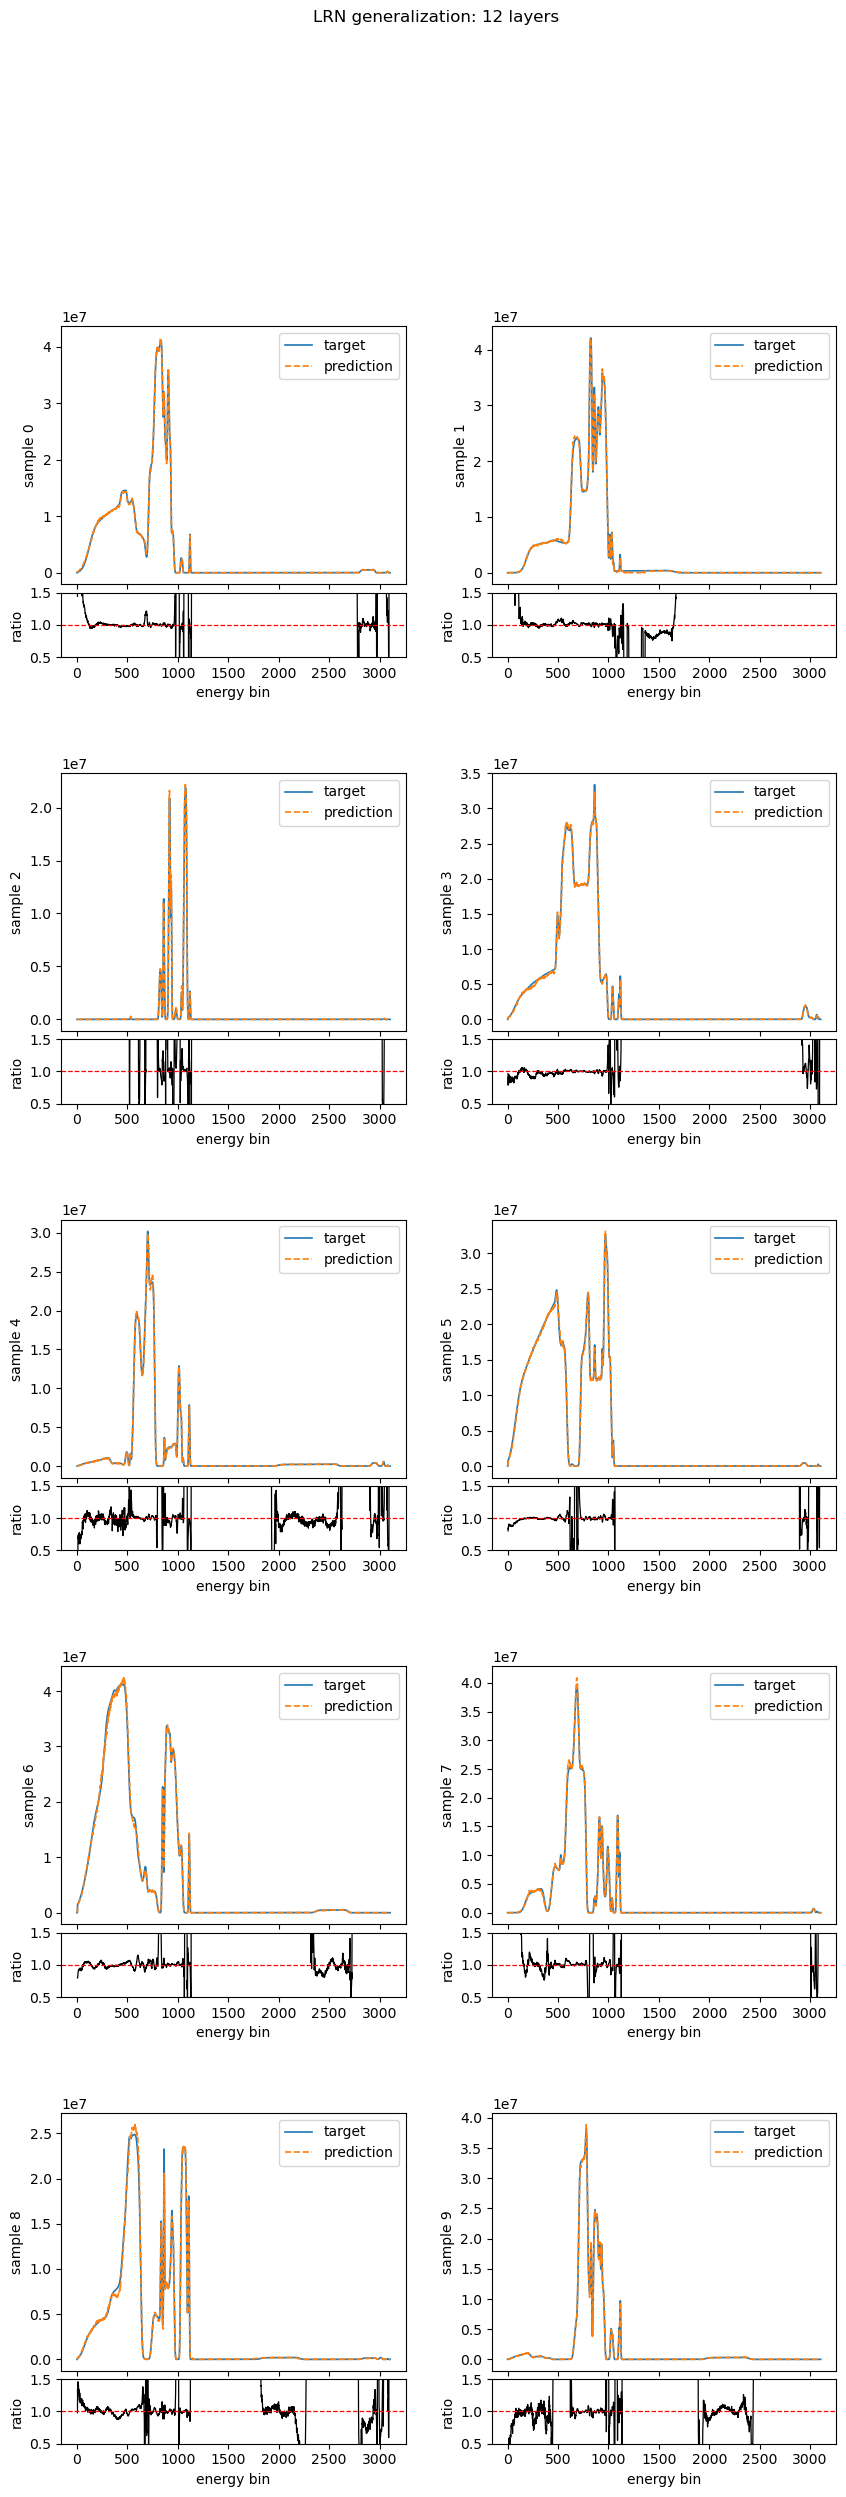

Saved figure: d:\IBAMLKit\examples\artifacts\rbs_e_space_predictions_upto7layermodel_12layers_generalization.pdf
Loaded generalization case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1_11_15_layers\layers_13: 1 file(s), samples=15000, n_layers=13


Rebinning RBS 13 layers output: 100%|██████████| 15000/15000 [00:00<00:00, 31893.60spectra/s]


Layer case 13: samples=15000, valid spectra=15000, min=0.017963, p01=0.0483476, p05=0.0709538, p10=0.0874066, p25=0.120686, p50=0.168315, p75=0.229117, p90=0.295081, p95=0.346655, p99=0.457658, mean=0.185669, max=16.5073


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\4031044095.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.985])


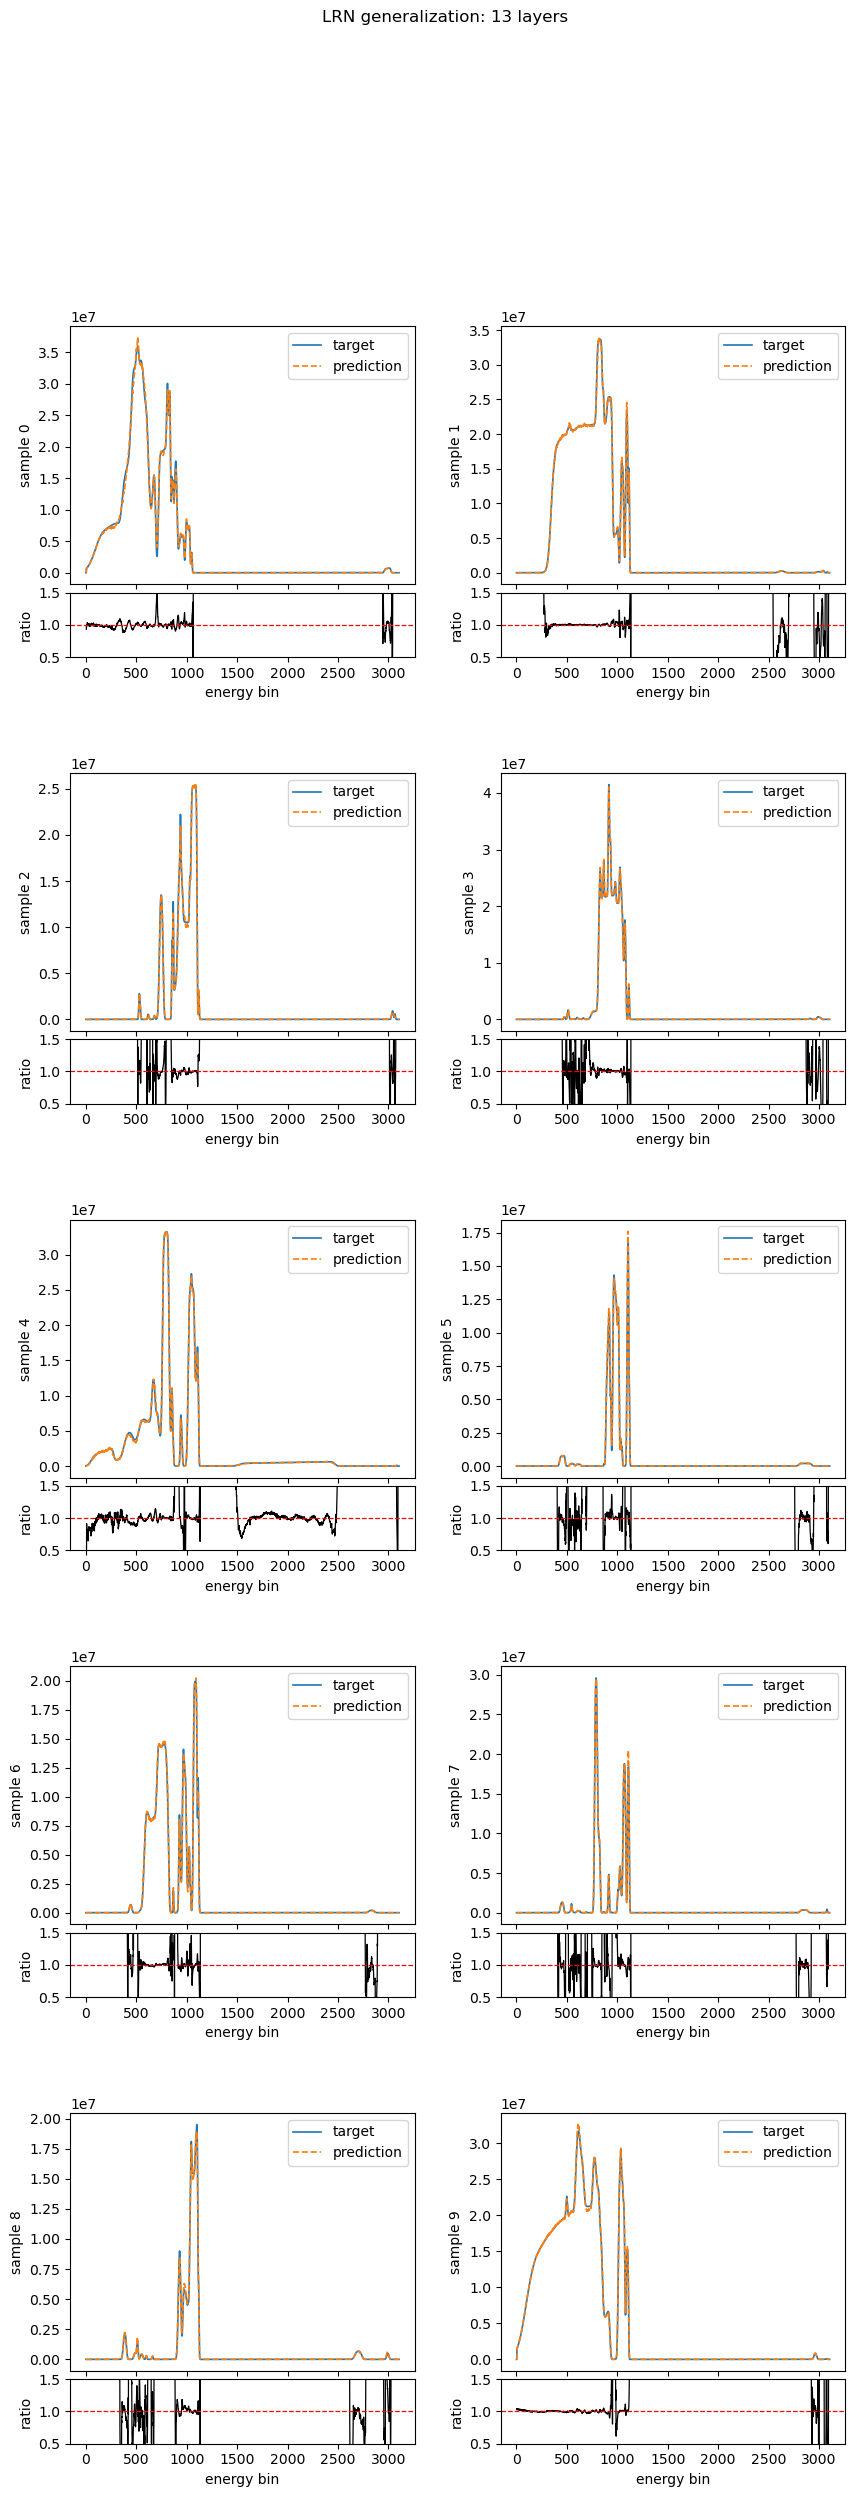

Saved figure: d:\IBAMLKit\examples\artifacts\rbs_e_space_predictions_upto7layermodel_13layers_generalization.pdf
Loaded generalization case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1_11_15_layers\layers_14: 1 file(s), samples=15000, n_layers=14


Rebinning RBS 14 layers output: 100%|██████████| 15000/15000 [00:00<00:00, 31788.89spectra/s]


Layer case 14: samples=15000, valid spectra=15000, min=0.0195122, p01=0.048787, p05=0.0712861, p10=0.0874692, p25=0.121836, p50=0.172796, p75=0.238507, p90=0.312599, p95=0.36531, p99=0.492457, mean=0.197145, max=33.9329


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\4031044095.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.985])


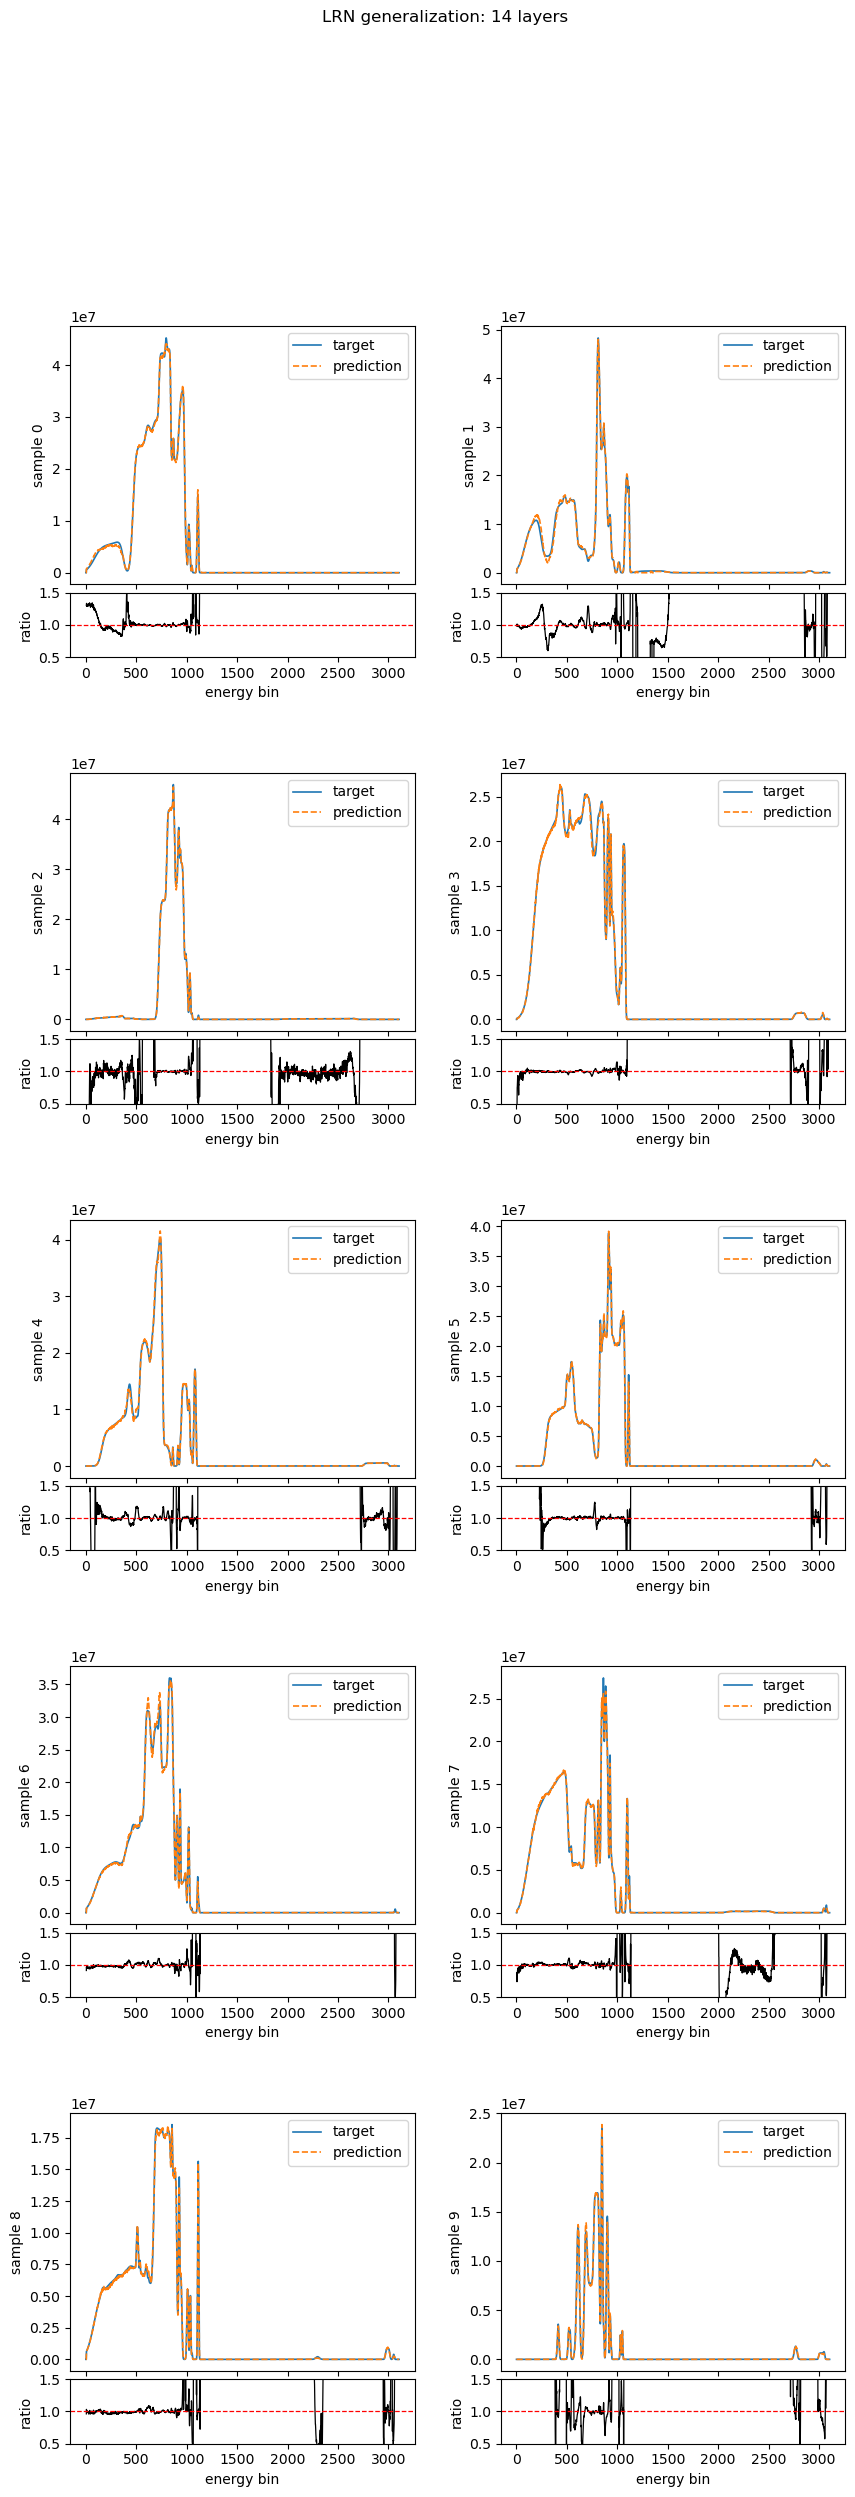

Saved figure: d:\IBAMLKit\examples\artifacts\rbs_e_space_predictions_upto7layermodel_14layers_generalization.pdf
Loaded generalization case D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1_11_15_layers\layers_15: 1 file(s), samples=15000, n_layers=15


Rebinning RBS 15 layers output: 100%|██████████| 15000/15000 [00:00<00:00, 31079.52spectra/s]


Layer case 15: samples=15000, valid spectra=15000, min=0.0154935, p01=0.0501379, p05=0.0731398, p10=0.0899123, p25=0.124346, p50=0.176078, p75=0.243575, p90=0.319296, p95=0.374354, p99=0.511443, mean=0.200075, max=14.1846


C:\Users\local_admin\AppData\Local\Temp\ipykernel_46828\4031044095.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.985])


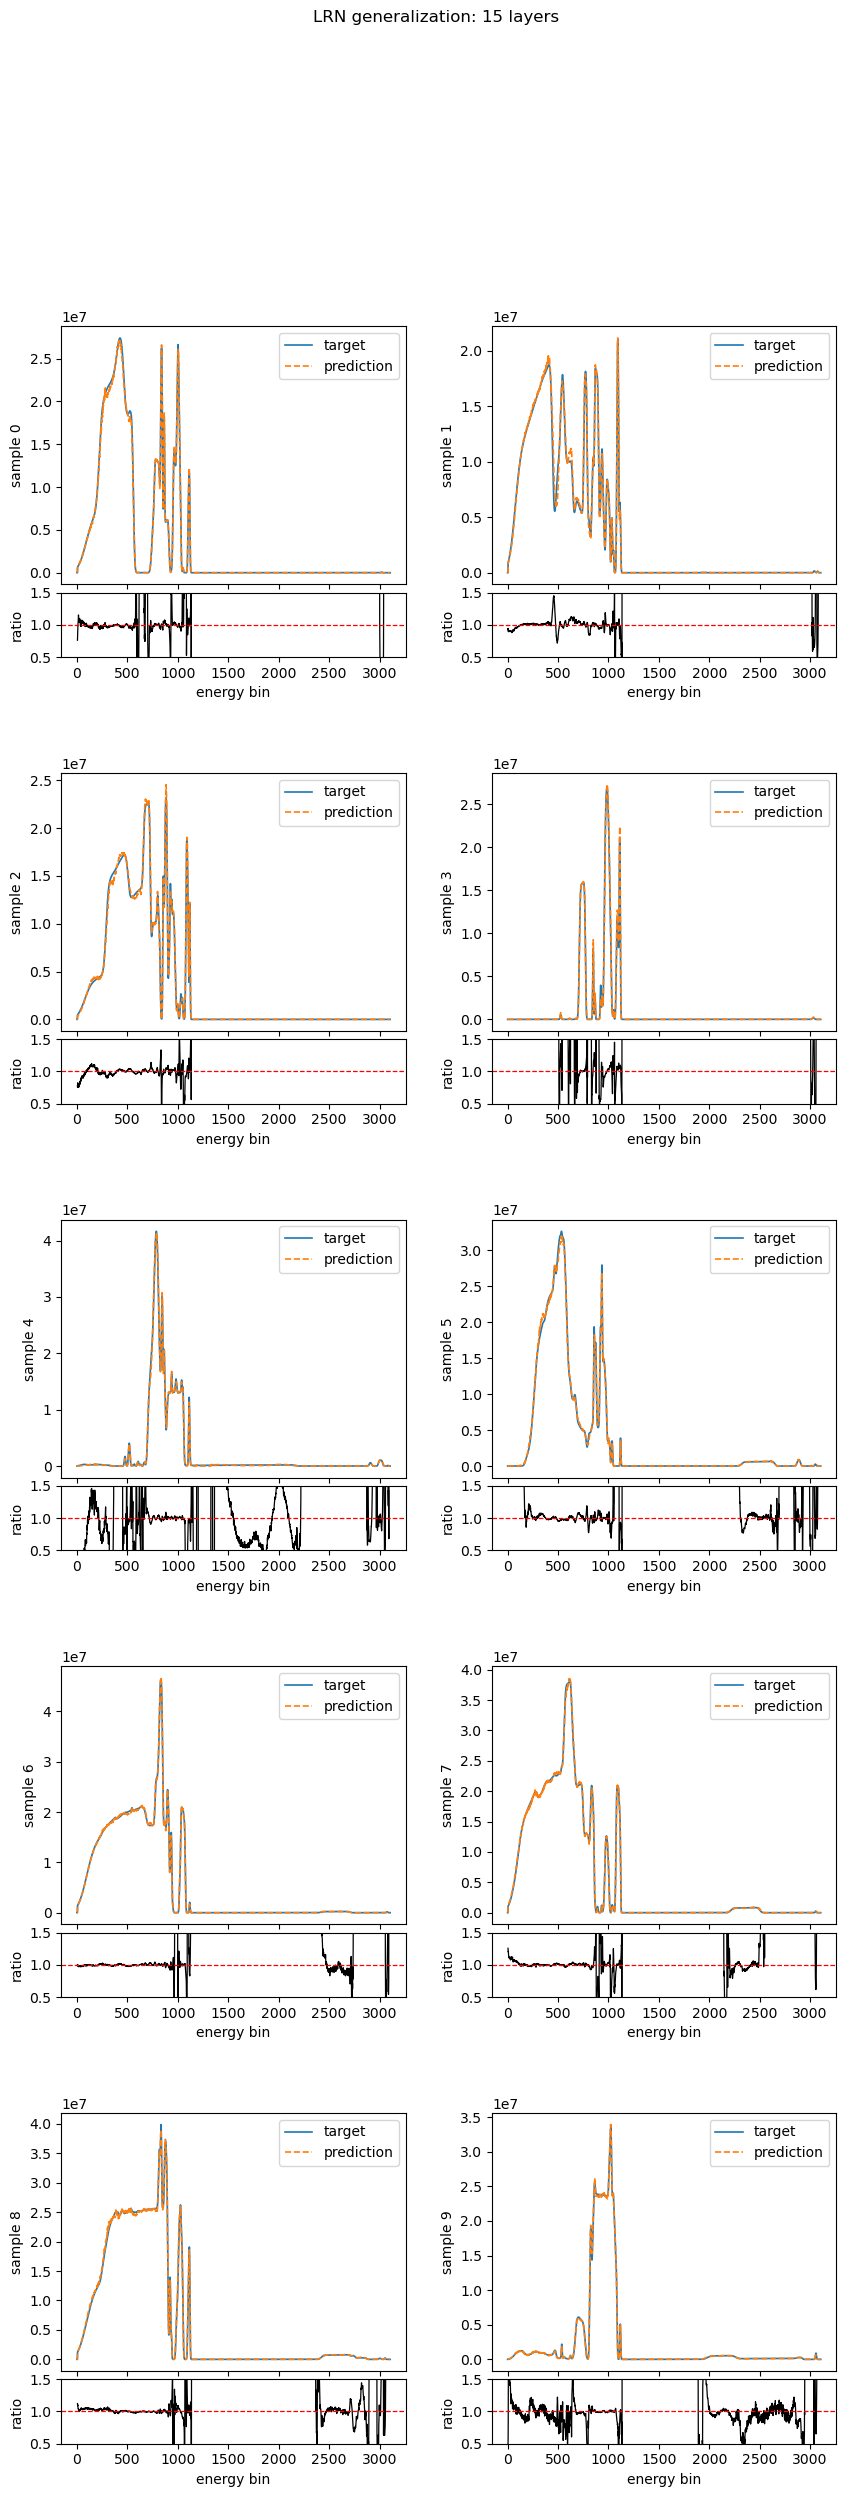

Saved figure: d:\IBAMLKit\examples\artifacts\rbs_e_space_predictions_upto7layermodel_15layers_generalization.pdf
Generalization summary:
  11 layers -> samples=15000, valid spectra=15000, min=0.017784, p01=0.043658, p05=0.0684102, p10=0.0843603, p25=0.116927, p50=0.16175, p75=0.219661, p90=0.279894, p95=0.326085, p99=0.437487, mean=0.175888, max=6.21676
  12 layers -> samples=15000, valid spectra=15000, min=0.015541, p01=0.0460749, p05=0.0694749, p10=0.0853257, p25=0.117941, p50=0.164773, p75=0.2227, p90=0.28745, p95=0.335449, p99=0.449147, mean=0.180108, max=8.43337
  13 layers -> samples=15000, valid spectra=15000, min=0.017963, p01=0.0483476, p05=0.0709538, p10=0.0874066, p25=0.120686, p50=0.168315, p75=0.229117, p90=0.295081, p95=0.346655, p99=0.457658, mean=0.185669, max=16.5073
  14 layers -> samples=15000, valid spectra=15000, min=0.0195122, p01=0.048787, p05=0.0712861, p10=0.0874692, p25=0.121836, p50=0.172796, p75=0.238507, p90=0.312599, p95=0.36531, p99=0.492457, mean=0.19714

In [9]:
generalization_root = Path(r"D:/IBAMLKit/examples/datasets/multilayer_7_elements_seed_1_11_15_layers")
generalization_root = require_absolute_directory(generalization_root)
generalization_case_groups = collect_dataset_file_groups(generalization_root, min_layer_number=11, max_layer_number=15)
generalization_summaries = []

for case_dir, paths in generalization_case_groups:
    dataset, _ = load_case_dataset(paths)
    n_layers = int(dataset.input_spec.generation_info.get("n_layers", 0))
    print(
        f"Loaded generalization case {case_dir}: {len(paths)} file(s), "
        f"samples={dataset.sample_count}, n_layers={n_layers}"
    )

    case_bootstrap_schema = build_lrn_model_schema(
        dataset.input_spec,
        model_name=f"lrn_{method_name.lower()}_{n_layers}layers",
        task_method_names=[method_name],
        output_spectra_lengths={method_name: 1},
    )
    case_prepared = prepare_variable_layer_surrogate_dataset(
        [dataset],
        schema=case_bootstrap_schema,
        method_name=method_name,
    )
    case_inputs = np.asarray(case_prepared.inputs_selected, dtype=np.float32)
    case_full_open_parameter_values = np.asarray(case_prepared.inputs_full, dtype=np.float32)
    case_channel_targets = np.asarray(case_prepared.targets, dtype=np.float32)
    case_channel_lengths = case_prepared.target_lengths

    if case_channel_lengths is not None:
        case_channel_lengths = np.asarray(case_channel_lengths, dtype=np.int32)
        valid_mask = case_channel_lengths > 0
        if not np.all(valid_mask):
            dropped_count = int((~valid_mask).sum())
            case_inputs = np.asarray(case_inputs[valid_mask], dtype=np.float32)
            case_full_open_parameter_values = np.asarray(case_full_open_parameter_values[valid_mask], dtype=np.float32)
            case_channel_targets = np.asarray(case_channel_targets[valid_mask], dtype=np.float32)
            case_channel_lengths = np.asarray(case_channel_lengths[valid_mask], dtype=np.int32)
            print(f"Discarded {dropped_count} invalid samples for layer case {n_layers}.")
    else:
        case_channel_lengths = np.full((case_inputs.shape[0],), case_channel_targets.shape[1], dtype=np.int32)

    case_open_parameter_names = [parameter.name for parameter in dataset.input_spec.open_parameters]
    case_calibration_offset, case_calibration_linear, case_calibration_quadratic, case_normalization_factor = resolve_channel_conversion_arrays(
        dataset.input_spec,
        case_open_parameter_names,
        case_full_open_parameter_values,
        method_name=method_name,
        energy_spectrum_scale=energy_spectrum_scale,
    )

    case_energy_targets_scaled = np.empty((case_inputs.shape[0], y.shape[1]), dtype=np.float32)
    rebin_spectra_to_energy_space(
        case_channel_targets,
        case_channel_lengths,
        calibration_offset=case_calibration_offset,
        calibration_linear=case_calibration_linear,
        calibration_quadratic=case_calibration_quadratic,
        energy_bin_width=energy_bin_width,
        target_width=int(y.shape[1]),
        energy_spectrum_scale=target_scale_factor,
        energy_edges=energy_bin_edges,
        out=case_energy_targets_scaled,
        show_progress=True,
        progress_desc=f"Rebinning {method_name} {n_layers} layers",
    )

    case_inputs_scaled = input_scaler.transform(case_inputs)
    lrn_model.eval()
    case_pred_transformed = lrn_model.predict(case_inputs_scaled).cpu().numpy()
    case_pred_e = np.empty_like(case_pred_transformed, dtype=np.float32)
    output_transform.inverse_transform(case_pred_transformed, out=case_pred_e)
    case_target_e = np.empty_like(case_energy_targets_scaled, dtype=np.float32)
    output_transform.inverse_transform(case_energy_targets_scaled, out=case_target_e)
    del case_pred_transformed

    valid_bin_mask = case_target_e > 1e+4
    sample_rel_err_means = []

    for sample_index in range(case_target_e.shape[0]):
        sample_mask = valid_bin_mask[sample_index]
        if not np.any(sample_mask):
            continue

        sample_rel_err = (
            np.abs(case_target_e[sample_index, sample_mask] - case_pred_e[sample_index, sample_mask])
            / case_target_e[sample_index, sample_mask]
        ).astype(np.float64)

        sample_rel_err_means.append(np.mean(sample_rel_err))

    sample_rel_err_means = np.asarray(sample_rel_err_means, dtype=np.float64)

    if sample_rel_err_means.size == 0:
        print(f"Layer case {n_layers}: no spectra have bins with data > 10, skipping summary.")
        err_stats = None
    else:
        err_stats = {
            "min": float(np.min(sample_rel_err_means)),
            "p01": float(np.percentile(sample_rel_err_means, 1.0)),
            "p05": float(np.percentile(sample_rel_err_means, 5.0)),
            "p10": float(np.percentile(sample_rel_err_means, 10.0)),
            "p25": float(np.percentile(sample_rel_err_means, 25.0)),
            "p50": float(np.percentile(sample_rel_err_means, 50.0)),
            "p75": float(np.percentile(sample_rel_err_means, 75.0)),
            "p90": float(np.percentile(sample_rel_err_means, 90.0)),
            "p95": float(np.percentile(sample_rel_err_means, 95.0)),
            "p99": float(np.percentile(sample_rel_err_means, 99.0)),
            "mean": float(np.mean(sample_rel_err_means)),
            "max": float(np.max(sample_rel_err_means)),
            "count": int(sample_rel_err_means.size),
        }

        print(
            f"Layer case {n_layers}: samples={case_inputs.shape[0]}, "
            f"valid spectra={err_stats['count']}, "
            f"min={err_stats['min']:.6g}, "
            f"p01={err_stats['p01']:.6g}, "
            f"p05={err_stats['p05']:.6g}, "
            f"p10={err_stats['p10']:.6g}, "
            f"p25={err_stats['p25']:.6g}, "
            f"p50={err_stats['p50']:.6g}, "
            f"p75={err_stats['p75']:.6g}, "
            f"p90={err_stats['p90']:.6g}, "
            f"p95={err_stats['p95']:.6g}, "
            f"p99={err_stats['p99']:.6g}, "
            f"mean={err_stats['mean']:.6g}, "
            f"max={err_stats['max']:.6g}"
        )

    generalization_summaries.append(
        {
            "n_layers": n_layers,
            "sample_count": int(case_inputs.shape[0]),
            "valid_spectra": int(sample_rel_err_means.size),
            "err_stats": err_stats,
        }
    )

    n_plot = min(10, case_inputs.shape[0])
    n_cols = 2
    n_rows = int(np.ceil(n_plot / n_cols))

    fig = plt.figure(figsize=(10, 5.5 * n_rows))
    outer = fig.add_gridspec(n_rows, n_cols, wspace=0.25, hspace=0.35)

    for panel_index in range(n_plot):
        row = panel_index // n_cols
        col = panel_index % n_cols

        inner = outer[row, col].subgridspec(2, 1, height_ratios=[4, 1], hspace=0.05)
        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        target = case_target_e[panel_index]
        pred = case_pred_e[panel_index]

        ratio = np.full_like(target, np.nan, dtype=np.float32)
        ratio_mask = target > 0.0
        ratio[ratio_mask] = pred[ratio_mask] / target[ratio_mask]

        ax_top.plot(target, label="target", linewidth=1.2)
        ax_top.plot(pred, linestyle="--", label="prediction", linewidth=1.2)
        ax_top.set_ylabel(f"sample {panel_index}")
        #ax_top.set_ylim(0.0, 1000)
        if panel_index == 0:pass
        ax_top.legend()

        ax_bottom.plot(ratio, color="black", linewidth=0.9)
        ax_bottom.axhline(1.0, color="red", linestyle="--", linewidth=0.9)
        ax_bottom.set_ylabel("ratio")
        ax_bottom.set_xlabel("energy bin")
        ax_bottom.set_ylim(0.5, 1.5)

        plt.setp(ax_top.get_xticklabels(), visible=False)

    for panel_index in range(n_plot, n_rows * n_cols):
        row = panel_index // n_cols
        col = panel_index % n_cols
        ax_empty = fig.add_subplot(outer[row, col])
        ax_empty.set_visible(False)

    fig.suptitle(f"LRN generalization: {n_layers} layers", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.985])

    figure_path = artifact_dir / f"{method_name.lower()}_e_space_predictions_upto7layermodel_{n_layers}layers_generalization.pdf"
    fig.savefig(figure_path, bbox_inches="tight")
    plt.show()
    print("Saved figure:", figure_path)

    del case_prepared, case_inputs, case_full_open_parameter_values, case_channel_targets
    del case_channel_lengths, case_energy_targets_scaled, case_inputs_scaled
    del case_pred_e, case_target_e, sample_rel_err_means
    gc.collect()

print("Generalization summary:")
for item in generalization_summaries:
    n_layers = item["n_layers"]
    sample_count = item["sample_count"]
    valid_spectra = item["valid_spectra"]
    err_stats = item["err_stats"]

    if err_stats is None:
        print(f"  {n_layers} layers -> samples={sample_count}, no spectra with bins > 10")
    else:
        print(
            f"  {n_layers} layers -> samples={sample_count}, valid spectra={valid_spectra}, "
            f"min={err_stats['min']:.6g}, "
            f"p01={err_stats['p01']:.6g}, "
            f"p05={err_stats['p05']:.6g}, "
            f"p10={err_stats['p10']:.6g}, "
            f"p25={err_stats['p25']:.6g}, "
            f"p50={err_stats['p50']:.6g}, "
            f"p75={err_stats['p75']:.6g}, "
            f"p90={err_stats['p90']:.6g}, "
            f"p95={err_stats['p95']:.6g}, "
            f"p99={err_stats['p99']:.6g}, "
            f"mean={err_stats['mean']:.6g}, "
            f"max={err_stats['max']:.6g}"
        )